# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys
sys.path.append('/Users/huez/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [2]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [5]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.7s to complete
    error(train)=7.72e-01, acc(train)=7.60e-01, error(valid)=7.87e-01, acc(valid)=7.58e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 3: 3.7s to complete
    error(train)=5.02e-01, acc(train)=8.36e-01, error(valid)=5.56e-01, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 3.6s to complete
    error(train)=4.68e-01, acc(train)=8.43e-01, error(valid)=5.45e-01, acc(valid)=8.22e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 3.7s to complete
    error(train)=4.46e-01, acc(train)=8.42e-01, error(valid)=5.39e-01, acc(valid)=8.17e-01


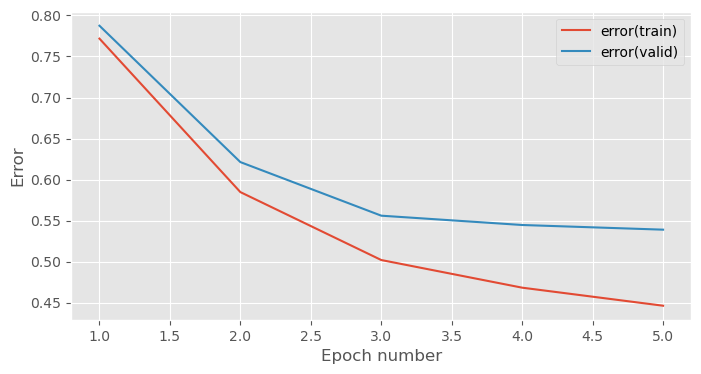

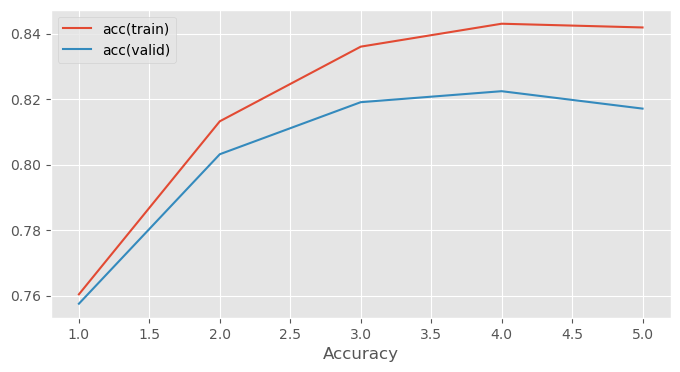

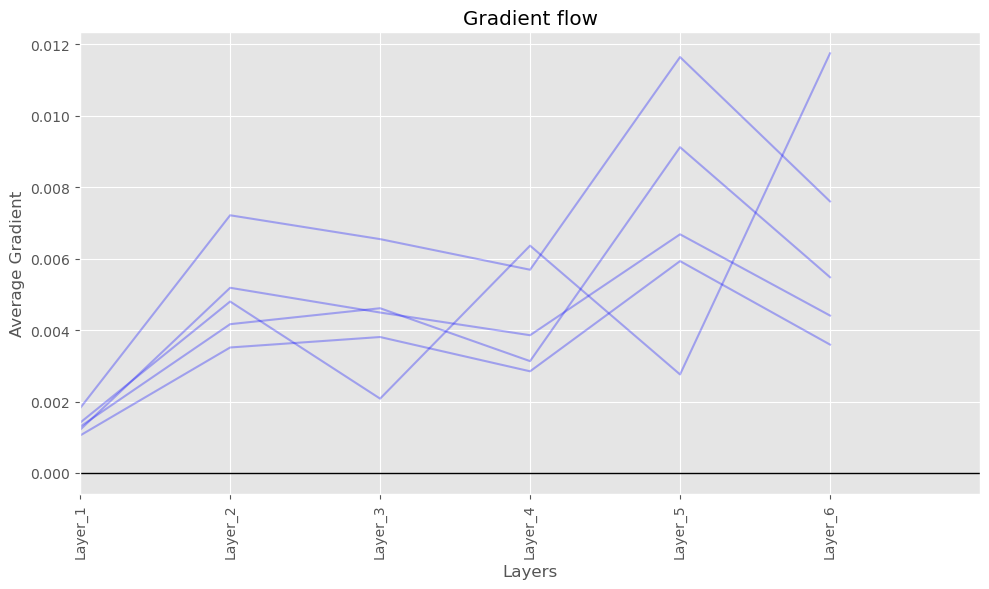

In [6]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 5.4s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.09e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 5.1s to complete
    error(train)=3.85e+00, acc(train)=2.12e-02, error(valid)=3.85e+00, acc(valid)=2.16e-02


...

Epoch 3: 4.9s to complete
    error(train)=3.85e+00, acc(train)=2.11e-02, error(valid)=3.85e+00, acc(valid)=2.13e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 5.0s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.28e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 4.7s to complete
    error(train)=3.85e+00, acc(train)=2.14e-02, error(valid)=3.85e+00, acc(valid)=2.09e-02


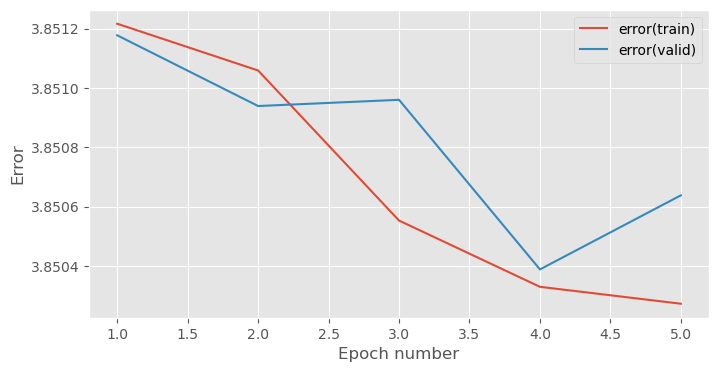

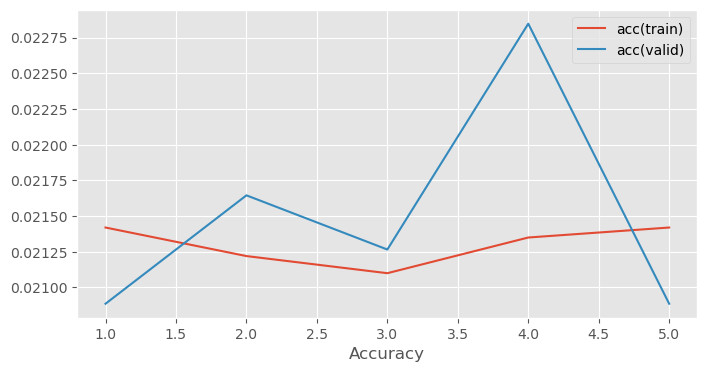

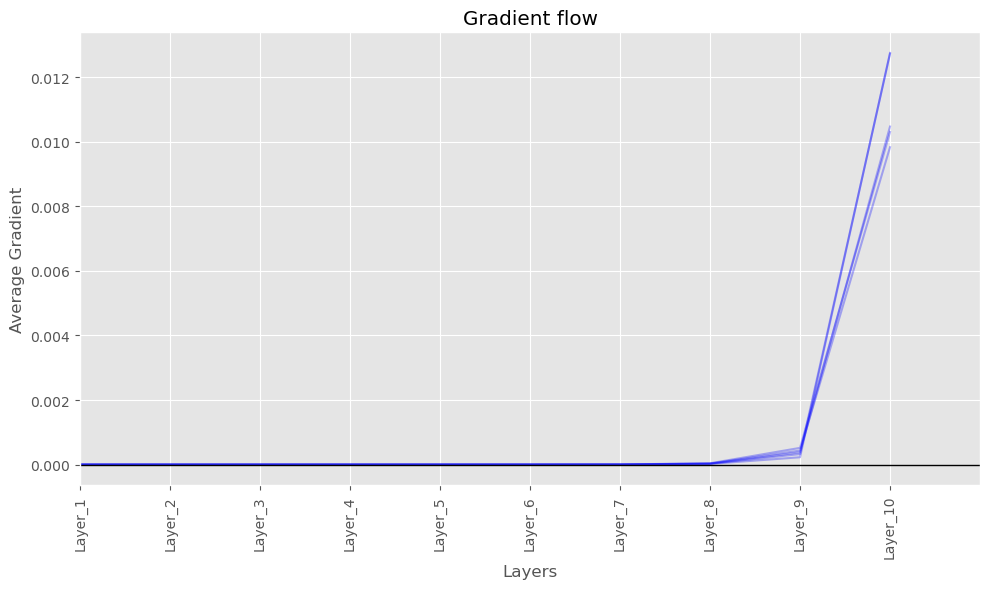

In [7]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

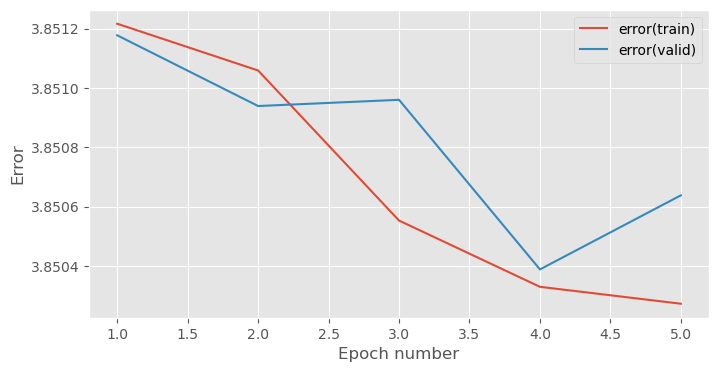

In [8]:
# You can then check the plots like this
fig_1 # The training error plot

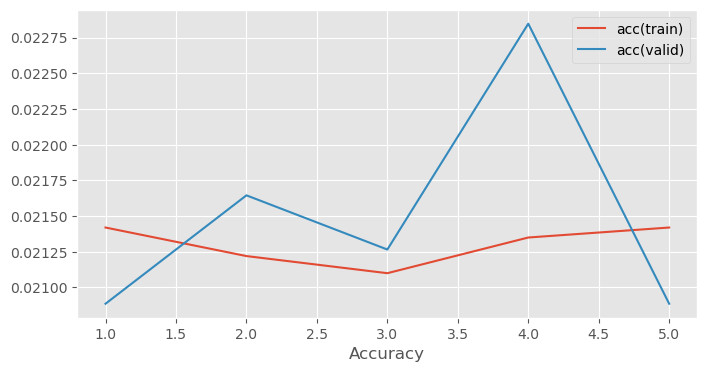

In [9]:
fig_2 # The training accuracy plot

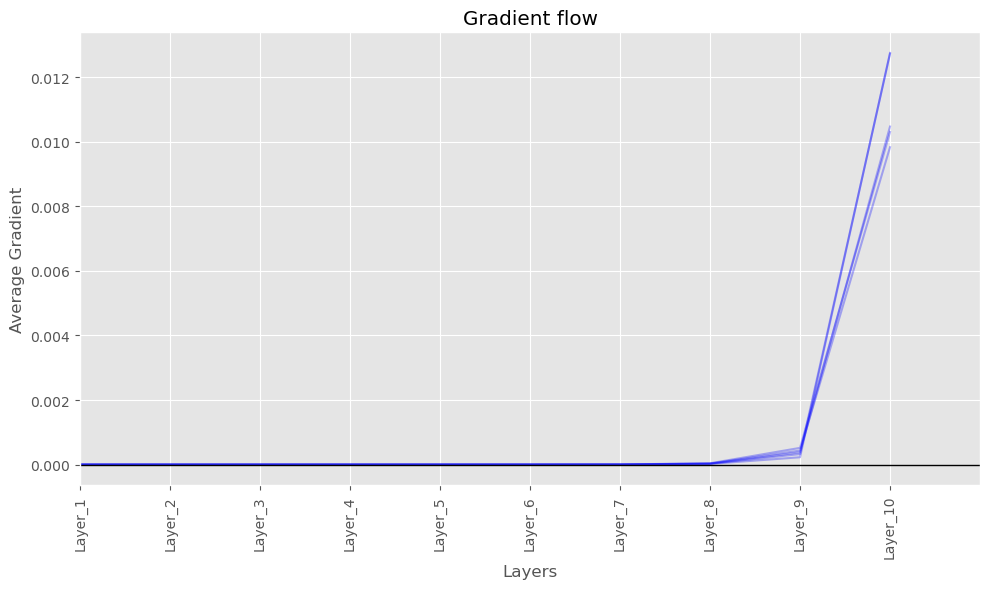

In [10]:
grad_plot # The gradient flow plot

In [11]:
# Setup common hyperparameters
learning_rate = 0.001
num_epochs = 100  # 根据你的需要调整
stats_interval = 1
input_dim, output_dim = 784, 47
batch_size = 100
seed = 111020

# Set up logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Define the hidden dimensions to test
hidden_dims = [32, 64, 128]

# Store results for all experiments
all_stats = {}
all_keys = {}

# Run experiments for each hidden dimension
for hidden_dim in hidden_dims:
    print(f"\n{'='*60}")
    print(f"Training with {hidden_dim} hidden units")
    print(f"{'='*60}\n")
    
    # Reset data providers for each experiment
    rng = np.random.RandomState(seed)
    train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
    valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)
    
    # Initialize weights
    weights_init = GlorotUniformInit(rng=rng)
    biases_init = ConstantInit(0.)
    
    # Create model with ONE hidden layer (for width experiment)
    model = MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
        ReluLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
    ])
    
    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=learning_rate)
    
    # Set up data monitors
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}
    
    # Train the model
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, 
        data_monitors, notebook=True
    )
    
    stats, keys, run_time = optimiser.train(
        num_epochs=num_epochs, 
        stats_interval=stats_interval
    )
    
    # Store results
    all_stats[hidden_dim] = stats
    all_keys[hidden_dim] = keys
    
    print(f"\nCompleted training with {hidden_dim} hidden units")
    print(f"Final validation accuracy: {stats[-1, keys['acc(valid)']]:.3f}")
    print(f"Final training error: {stats[-1, keys['error(train)']]:.3f}")
    print(f"Final validation error: {stats[-1, keys['error(valid)']]:.3f}")


Training with 32 hidden units

KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 15.6s to complete
    error(train)=1.23e+00, acc(train)=6.58e-01, error(valid)=1.24e+00, acc(valid)=6.55e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 5.2s to complete
    error(train)=1.55e-01, acc(train)=9.40e-01, error(valid)=9.63e-01, acc(valid)=8.04e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.7s to complete
    error(train)=1.56e-01, acc(train)=9.40e-01, error(valid)=9.75e-01, acc(valid)=8.07e-01



Completed training with 128 hidden units
Final validation accuracy: 0.807
Final training error: 0.156
Final validation error: 0.975


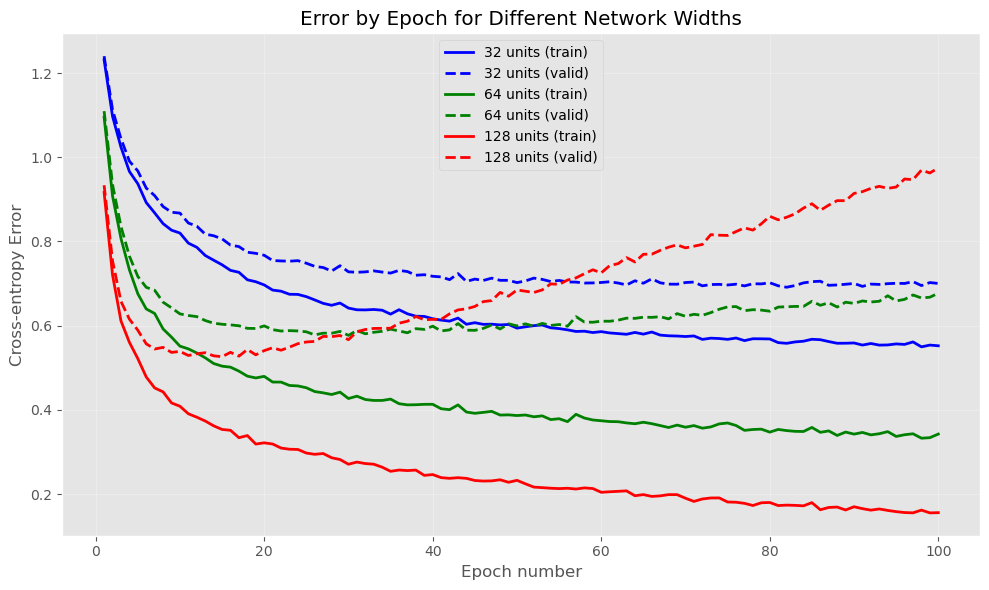

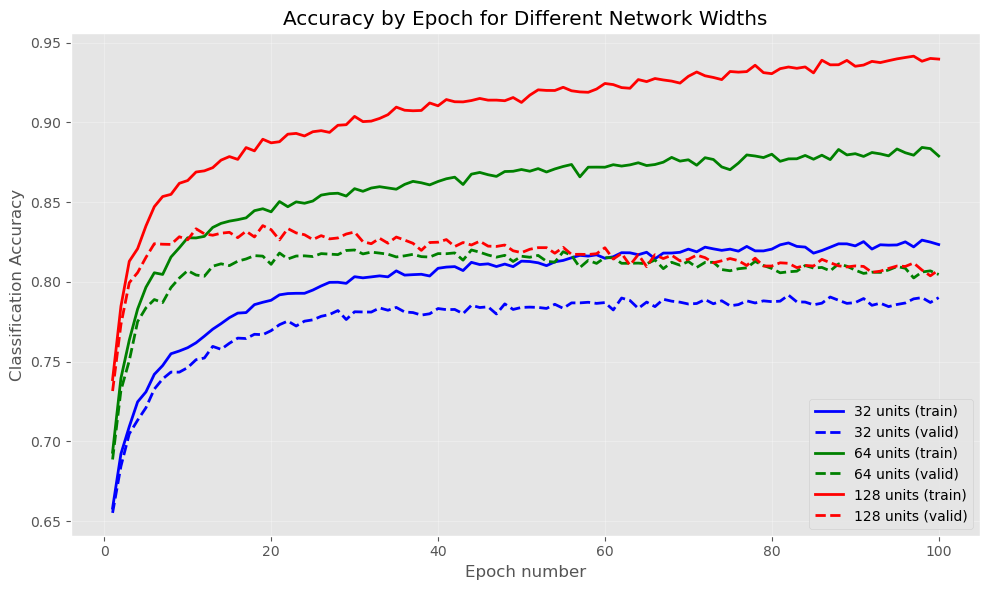

In [12]:
# Create Figure 2 - Width comparison plots

# Define colors for different widths
colors = {32: 'blue', 64: 'green', 128: 'red'}
epochs = np.arange(1, all_stats[32].shape[0]) * stats_interval

# Create error curves (Figure 2b)
fig_error = plt.figure(figsize=(10, 6))
ax_error = fig_error.add_subplot(111)

for hidden_dim in hidden_dims:
    stats = all_stats[hidden_dim]
    keys = all_keys[hidden_dim]
    color = colors[hidden_dim]
    
    # Plot training error (solid line)
    ax_error.plot(epochs, stats[1:, keys['error(train)']], 
                  color=color, linestyle='-', linewidth=2,
                  label=f'{hidden_dim} units (train)')
    
    # Plot validation error (dashed line)
    ax_error.plot(epochs, stats[1:, keys['error(valid)']], 
                  color=color, linestyle='--', linewidth=2,
                  label=f'{hidden_dim} units (valid)')

ax_error.set_xlabel('Epoch number', fontsize=12)
ax_error.set_ylabel('Cross-entropy Error', fontsize=12)
ax_error.legend(loc='best', fontsize=10)
ax_error.set_title('Error by Epoch for Different Network Widths')
ax_error.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/huez/mlpractical/report/figures/empty_error_curve_width.png', dpi=300, bbox_inches='tight')
plt.show()

# Create accuracy curves (Figure 2a)
fig_acc = plt.figure(figsize=(10, 6))
ax_acc = fig_acc.add_subplot(111)

for hidden_dim in hidden_dims:
    stats = all_stats[hidden_dim]
    keys = all_keys[hidden_dim]
    color = colors[hidden_dim]
    
    # Plot training accuracy (solid line)
    ax_acc.plot(epochs, stats[1:, keys['acc(train)']], 
                color=color, linestyle='-', linewidth=2,
                label=f'{hidden_dim} units (train)')
    
    # Plot validation accuracy (dashed line)
    ax_acc.plot(epochs, stats[1:, keys['acc(valid)']], 
                color=color, linestyle='--', linewidth=2,
                label=f'{hidden_dim} units (valid)')

ax_acc.set_xlabel('Epoch number', fontsize=12)
ax_acc.set_ylabel('Classification Accuracy', fontsize=12)
ax_acc.legend(loc='best', fontsize=10)
ax_acc.set_title('Accuracy by Epoch for Different Network Widths')
ax_acc.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/huez/mlpractical/report/figures/empty_acc_curve_width.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
print("\\midrule")
for hidden_dim in [32, 64, 128]:
    stats = all_stats[hidden_dim]
    keys = all_keys[hidden_dim]
    val_acc = stats[-1, keys['acc(valid)']] * 100
    train_error = stats[-1, keys['error(train)']]
    val_error = stats[-1, keys['error(valid)']]
    print(f"     {hidden_dim:<3}            &    {val_acc:.1f}   &  {train_error:.3f} &   {val_error:.3f}            \\\\")
print("\\bottomrule")

\midrule
     32             &    79.0   &  0.552 &   0.700            \\
     64             &    80.5   &  0.343 &   0.677            \\
     128            &    80.7   &  0.156 &   0.975            \\
\bottomrule


In [16]:

# Setup common hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim = 784, 47
hidden_dim = 128  # 固定每层的宽度
batch_size = 100
seed = 111020


# Create data providers (only once)
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

# Define the number of hidden layers to test
num_layers_list = [1, 2, 3]

# Store results for all experiments
all_stats_depth = {}
all_keys_depth = {}

# Run experiments for each depth
for num_layers in num_layers_list:
    print(f"\n{'='*60}")
    print(f"Training with {num_layers} hidden layer(s)")
    print(f"{'='*60}\n")
    
    # Reset data providers
    train_data.reset()
    valid_data.reset()
    
    # Initialize weights
    weights_rng = np.random.RandomState(seed)
    weights_init = GlorotUniformInit(rng=weights_rng)
    biases_init = ConstantInit(0.)
    
    # Build model with variable number of hidden layers
    layers = []
    
    # First hidden layer
    layers.append(AffineLayer(input_dim, hidden_dim, weights_init, biases_init))
    layers.append(ReluLayer())
    
    # Additional hidden layers (if num_layers > 1)
    for _ in range(num_layers - 1):
        layers.append(AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init))
        layers.append(ReluLayer())
    
    # Output layer
    layers.append(AffineLayer(hidden_dim, output_dim, weights_init, biases_init))
    
    # Create model
    model = MultipleLayerModel(layers)
    
    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=learning_rate)
    
    # Set up data monitors
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}
    
    # Train the model
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, 
        data_monitors, notebook=True
    )
    
    stats, keys, run_time = optimiser.train(
        num_epochs=num_epochs, 
        stats_interval=stats_interval
    )
    
    # Store results
    all_stats_depth[num_layers] = stats
    all_keys_depth[num_layers] = keys
    
    print(f"\nCompleted training with {num_layers} hidden layer(s)")
    print(f"Final validation accuracy: {stats[-1, keys['acc(valid)']]:.3f}")
    print(f"Final training error: {stats[-1, keys['error(train)']]:.3f}")
    print(f"Final validation error: {stats[-1, keys['error(valid)']]:.3f}")

KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)

Training with 1 hidden layer(s)



  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 5.8s to complete
    error(train)=8.90e-01, acc(train)=7.44e-01, error(valid)=9.05e-01, acc(valid)=7.38e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 6.1s to complete
    error(train)=1.04e-01, acc(train)=9.60e-01, error(valid)=1.67e+00, acc(valid)=8.21e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 6.3s to complete
    error(train)=1.13e-01, acc(train)=9.57e-01, error(valid)=1.73e+00, acc(valid)=8.21e-01



Completed training with 3 hidden layer(s)
Final validation accuracy: 0.821
Final training error: 0.113
Final validation error: 1.734


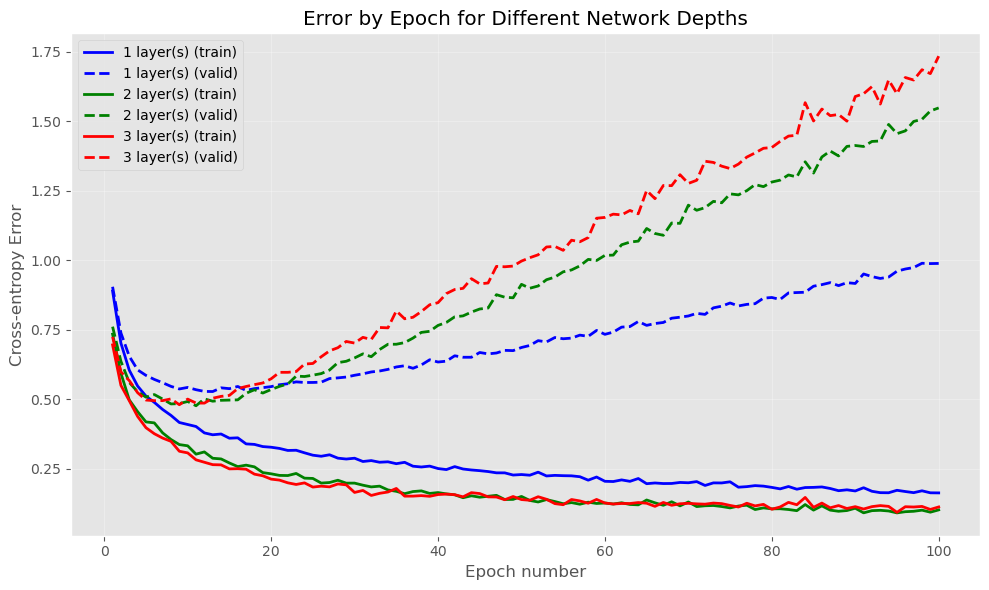

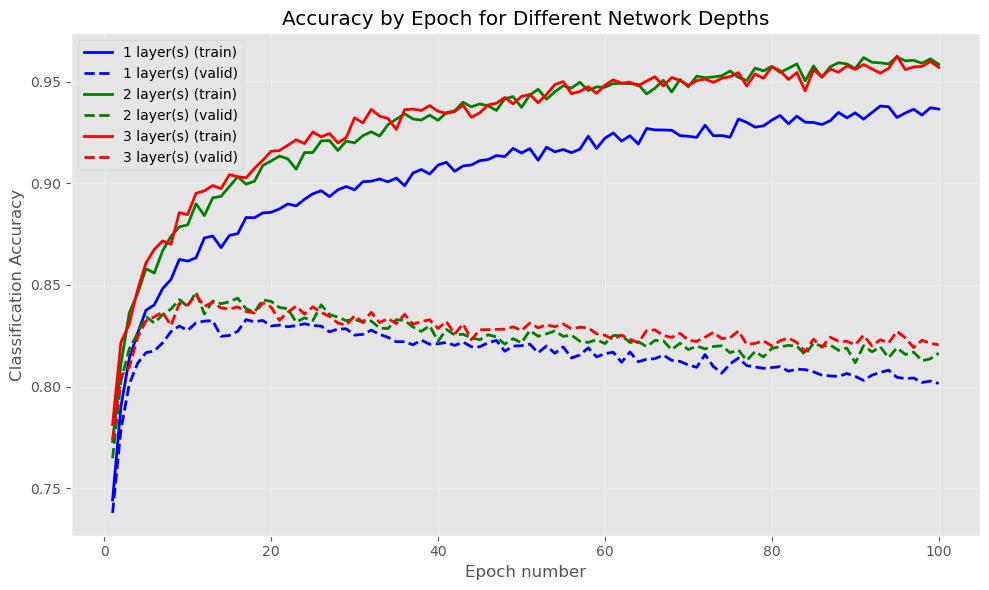

In [17]:
# Create Figure 3 - Depth comparison plots

# Define colors for different depths
colors = {1: 'blue', 2: 'green', 3: 'red'}
epochs = np.arange(1, all_stats_depth[1].shape[0]) * stats_interval

# Create error curves (Figure 3b)
fig_error = plt.figure(figsize=(10, 6))
ax_error = fig_error.add_subplot(111)

for num_layers in num_layers_list:
    stats = all_stats_depth[num_layers]
    keys = all_keys_depth[num_layers]
    color = colors[num_layers]
    
    # Plot training error (solid line)
    ax_error.plot(epochs, stats[1:, keys['error(train)']], 
                  color=color, linestyle='-', linewidth=2,
                  label=f'{num_layers} layer(s) (train)')
    
    # Plot validation error (dashed line)
    ax_error.plot(epochs, stats[1:, keys['error(valid)']], 
                  color=color, linestyle='--', linewidth=2,
                  label=f'{num_layers} layer(s) (valid)')

ax_error.set_xlabel('Epoch number', fontsize=12)
ax_error.set_ylabel('Cross-entropy Error', fontsize=12)
ax_error.legend(loc='best', fontsize=10)
ax_error.set_title('Error by Epoch for Different Network Depths')
ax_error.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/huez/mlpractical/report/figures/empty_error_curve_depth.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Create accuracy curves (Figure 3a)
fig_acc = plt.figure(figsize=(10, 6))
ax_acc = fig_acc.add_subplot(111)

for num_layers in num_layers_list:
    stats = all_stats_depth[num_layers]
    keys = all_keys_depth[num_layers]
    color = colors[num_layers]
    
    # Plot training accuracy (solid line)
    ax_acc.plot(epochs, stats[1:, keys['acc(train)']], 
                color=color, linestyle='-', linewidth=2,
                label=f'{num_layers} layer(s) (train)')
    
    # Plot validation accuracy (dashed line)
    ax_acc.plot(epochs, stats[1:, keys['acc(valid)']], 
                color=color, linestyle='--', linewidth=2,
                label=f'{num_layers} layer(s) (valid)')

ax_acc.set_xlabel('Epoch number', fontsize=12)
ax_acc.set_ylabel('Classification Accuracy', fontsize=12)
ax_acc.legend(loc='best', fontsize=10)
ax_acc.set_title('Accuracy by Epoch for Different Network Depths')
ax_acc.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/huez/mlpractical/report/figures/empty_acc_curve_depth.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [19]:

print("\\midrule")
for num_layers in num_layers_list:
    stats = all_stats_depth[num_layers]
    keys = all_keys_depth[num_layers]
    val_acc = stats[-1, keys['acc(valid)']] * 100
    train_error = stats[-1, keys['error(train)']]
    val_error = stats[-1, keys['error(valid)']]
    print(f"     {num_layers:<3}               &      {val_acc:.1f}      &   {train_error:.3f} & {val_error:.3f}                \\\\")
print("\\bottomrule")

\midrule
     1                 &      80.2      &   0.164 & 0.989                \\
     2                 &      81.6      &   0.103 & 1.548                \\
     3                 &      82.1      &   0.113 & 1.734                \\
\bottomrule


In [2]:
import mlp.layers
import mlp.penalties
from mlp.layers import DropoutLayer
from mlp.penalties import L1Penalty, L2Penalty, L1L2MixPenalty
# import importlib
# importlib.reload(mlp.layers)
# importlib.reload(mlp.penalties)
# Common hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128
batch_size = 100
seed = 111020

# Setup logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data providers (only once)
rng = np.random.RandomState(seed)
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

# Storage for results
table3_results = {}
table4_results = {}

print("Setup complete. Ready to run experiments.")

KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)
Setup complete. Ready to run experiments.


In [4]:




print("\n" + "="*70)
print("TABLE 3 - Experiment 1: Dropout inclusion probability = 0.7")
print("="*70)

# Reset data providers
train_data.reset()
valid_data.reset()

# Initialize weights
weights_rng = np.random.RandomState(seed)
weights_init = GlorotUniformInit(rng=weights_rng)
biases_init = ConstantInit(0.)

# Create model with Dropout
dropout_rng = np.random.RandomState(seed)
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    DropoutLayer(rng=dropout_rng, incl_prob=0.7),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

# Train model
optimiser = Optimiser(model, error, learning_rule, train_data, valid_data, 
                     data_monitors, notebook=True)
stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

# Store results
table3_results['Dropout_0.7'] = {
    'val_acc': stats[-1, keys['acc(valid)']] * 100,
    'train_error': stats[-1, keys['error(train)']],
    'val_error': stats[-1, keys['error(valid)']]
}

print(f"\nResults: Val Acc = {table3_results['Dropout_0.7']['val_acc']:.1f}%, "
      f"Train Error = {table3_results['Dropout_0.7']['train_error']:.3f}, "
      f"Val Error = {table3_results['Dropout_0.7']['val_error']:.3f}")


TABLE 3 - Experiment 1: Dropout inclusion probability = 0.7


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 4.7s to complete
    error(train)=9.60e-01, acc(train)=7.24e-01, error(valid)=9.72e-01, acc(valid)=7.21e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 3.3s to complete
    error(train)=3.01e-01, acc(train)=8.95e-01, error(valid)=5.52e-01, acc(valid)=8.33e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.5s to complete
    error(train)=2.99e-01, acc(train)=8.95e-01, error(valid)=5.47e-01, acc(valid)=8.36e-01



Results: Val Acc = 83.6%, Train Error = 0.299, Val Error = 0.547


In [5]:
# =============================================================================
# TABLE 3 - Experiment 2: L1 penalty coefficient = 1e-3
# =============================================================================

print("\n" + "="*70)
print("TABLE 3 - Experiment 2: L1 penalty coefficient = 1e-3")
print("="*70)

# Reset data providers
train_data.reset()
valid_data.reset()

# Initialize weights
weights_rng = np.random.RandomState(seed)
weights_init = GlorotUniformInit(rng=weights_rng)
biases_init = ConstantInit(0.)

# Create L1 penalty
l1_penalty = L1Penalty(1e-3)

# Create model with L1 regularization
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init,
                weights_penalty=l1_penalty),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init,
                weights_penalty=l1_penalty)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

# Train model
optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                     data_monitors, notebook=True)
stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

# Store results
table3_results['L1_1e-3'] = {
    'val_acc': stats[-1, keys['acc(valid)']] * 100,
    'train_error': stats[-1, keys['error(train)']],
    'val_error': stats[-1, keys['error(valid)']]
}

print(f"\nResults: Val Acc = {table3_results['L1_1e-3']['val_acc']:.1f}%, "
      f"Train Error = {table3_results['L1_1e-3']['train_error']:.3f}, "
      f"Val Error = {table3_results['L1_1e-3']['val_error']:.3f}")


TABLE 3 - Experiment 2: L1 penalty coefficient = 1e-3


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.2s to complete
    error(train)=1.44e+00, acc(train)=6.23e-01, error(valid)=1.44e+00, acc(valid)=6.21e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 3.6s to complete
    error(train)=1.06e+00, acc(train)=7.03e-01, error(valid)=1.06e+00, acc(valid)=7.01e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 4.1s to complete
    error(train)=1.06e+00, acc(train)=7.02e-01, error(valid)=1.06e+00, acc(valid)=7.00e-01



Results: Val Acc = 70.0%, Train Error = 1.062, Val Error = 1.064


In [6]:
# =============================================================================
# TABLE 3 - Experiment 3: L2 penalty coefficient = 1e-3
# =============================================================================

print("\n" + "="*70)
print("TABLE 3 - Experiment 3: L2 penalty coefficient = 1e-3")
print("="*70)

# Reset data providers
train_data.reset()
valid_data.reset()

# Initialize weights
weights_rng = np.random.RandomState(seed)
weights_init = GlorotUniformInit(rng=weights_rng)
biases_init = ConstantInit(0.)

# Create L2 penalty
l2_penalty = L2Penalty(1e-3)

# Create model with L2 regularization
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init,
                weights_penalty=l2_penalty),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init,
                weights_penalty=l2_penalty)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

# Train model
optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                     data_monitors, notebook=True)
stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

# Store results
table3_results['L2_1e-3'] = {
    'val_acc': stats[-1, keys['acc(valid)']] * 100,
    'train_error': stats[-1, keys['error(train)']],
    'val_error': stats[-1, keys['error(valid)']]
}

print(f"\nResults: Val Acc = {table3_results['L2_1e-3']['val_acc']:.1f}%, "
      f"Train Error = {table3_results['L2_1e-3']['train_error']:.3f}, "
      f"Val Error = {table3_results['L2_1e-3']['val_error']:.3f}")


TABLE 3 - Experiment 3: L2 penalty coefficient = 1e-3


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.1s to complete
    error(train)=1.02e+00, acc(train)=7.14e-01, error(valid)=1.03e+00, acc(valid)=7.06e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 3.4s to complete
    error(train)=6.00e-01, acc(train)=8.23e-01, error(valid)=6.18e-01, acc(valid)=8.16e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.1s to complete
    error(train)=6.00e-01, acc(train)=8.22e-01, error(valid)=6.24e-01, acc(valid)=8.14e-01



Results: Val Acc = 81.4%, Train Error = 0.600, Val Error = 0.624


In [7]:
# =============================================================================
# TABLE 3 - Experiment 4: Label Smoothing alpha = 0.1
# =============================================================================

print("\n" + "="*70)
print("TABLE 3 - Experiment 4: Label Smoothing alpha = 0.1")
print("="*70)

# Create new data providers with label smoothing enabled
train_data_smooth = EMNISTDataProvider('train', batch_size=batch_size, rng=rng,
                                       smooth_labels=True)
valid_data_smooth = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng,
                                       smooth_labels=False)

# Initialize weights
weights_rng = np.random.RandomState(seed)
weights_init = GlorotUniformInit(rng=weights_rng)
biases_init = ConstantInit(0.)

# Create model (no regularization, only label smoothing)
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)
data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

# Train model
optimiser = Optimiser(model, error, learning_rule, train_data_smooth, valid_data_smooth,
                     data_monitors, notebook=True)
stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

# Store results
table3_results['LabelSmooth_0.1'] = {
    'val_acc': stats[-1, keys['acc(valid)']] * 100,
    'train_error': stats[-1, keys['error(train)']],
    'val_error': stats[-1, keys['error(valid)']]
}

print(f"\nResults: Val Acc = {table3_results['LabelSmooth_0.1']['val_acc']:.1f}%, "
      f"Train Error = {table3_results['LabelSmooth_0.1']['train_error']:.3f}, "
      f"Val Error = {table3_results['LabelSmooth_0.1']['val_error']:.3f}")


TABLE 3 - Experiment 4: Label Smoothing alpha = 0.1
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/huez/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.6s to complete
    error(train)=1.52e+00, acc(train)=7.55e-01, error(valid)=9.89e-01, acc(valid)=7.48e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 3.5s to complete
    error(train)=1.06e+00, acc(train)=9.09e-01, error(valid)=6.47e-01, acc(valid)=8.24e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.9s to complete
    error(train)=1.06e+00, acc(train)=9.11e-01, error(valid)=6.46e-01, acc(valid)=8.30e-01



Results: Val Acc = 83.0%, Train Error = 1.060, Val Error = 0.646


In [8]:
# =============================================================================
# TABLE 3 - Summary of Missing Values (LaTeX Format)
# =============================================================================

print("\n" + "="*80)
print("TABLE 3 - MISSING VALUES SUMMARY (LaTeX Format)")
print("="*80)

print("\nCopy the following lines into your .tex file:\n")
print("% Dropout 0.7:")
print(f"                 & 0.7 & {table3_results['Dropout_0.7']['val_acc']:.1f} & "
      f"{table3_results['Dropout_0.7']['train_error']:.3f} & "
      f"{table3_results['Dropout_0.7']['val_error']:.3f}  \\\\")

print("\n% L1 penalty 1e-3:")
print(f"                 & 1e-3 & {table3_results['L1_1e-3']['val_acc']:.1f} & "
      f"{table3_results['L1_1e-3']['train_error']:.3f} & "
      f"{table3_results['L1_1e-3']['val_error']:.3f} \\\\")

print("\n% L2 penalty 1e-3:")
print(f"                 & 1e-3 & {table3_results['L2_1e-3']['val_acc']:.1f} & "
      f"{table3_results['L2_1e-3']['train_error']:.3f} & "
      f"{table3_results['L2_1e-3']['val_error']:.3f} \\\\")

print("\n% Label smoothing 0.1:")
print(f"        Label smoothing & 0.1 & {table3_results['LabelSmooth_0.1']['val_acc']:.1f} & "
      f"{table3_results['LabelSmooth_0.1']['train_error']:.3f} & "
      f"{table3_results['LabelSmooth_0.1']['val_error']:.3f} \\\\")

print("\n" + "="*80)


TABLE 3 - MISSING VALUES SUMMARY (LaTeX Format)

Copy the following lines into your .tex file:

% Dropout 0.7:
                 & 0.7 & 83.6 & 0.299 & 0.547  \\

% L1 penalty 1e-3:
                 & 1e-3 & 70.0 & 1.062 & 1.064 \\

% L2 penalty 1e-3:
                 & 1e-3 & 81.4 & 0.600 & 0.624 \\

% Label smoothing 0.1:
        Label smoothing & 0.1 & 83.0 & 1.060 & 0.646 \\



In [3]:
# =============================================================================
# TABLE 4 - L1+L2 Elastic Net Combination Experiments
# =============================================================================

# Reset to normal data providers
train_data.reset()
valid_data.reset()

# Define 4 configurations to test
configs = [
    {'l1': 5e-4, 'l2': 5e-4, 'name': 'Conservative'},
    {'l1': 1e-4, 'l2': 5e-4, 'name': 'L2-dominant-1'},
    {'l1': 5e-4, 'l2': 1e-3, 'name': 'Balanced'},
    {'l1': 1e-4, 'l2': 1e-3, 'name': 'L2-dominant-2'},
]

for config in configs:
    l1_coef = config['l1']
    l2_coef = config['l2']
    name = config['name']
    
    print(f"\n{'='*70}")
    print(f"TABLE 4 - Experiment: {name} (L1={l1_coef}, L2={l2_coef})")
    print(f"{'='*70}")
    
    # Reset data providers
    train_data.reset()
    valid_data.reset()
    
    # Initialize weights
    weights_rng = np.random.RandomState(seed)
    weights_init = GlorotUniformInit(rng=weights_rng)
    biases_init = ConstantInit(0.)
    
    # Create combined L1+L2 penalty
    penalty = L1L2MixPenalty(l1_coefficient=l1_coef, l2_coefficient=l2_coef)
    
    # Create model with Elastic Net regularization
    model = MultipleLayerModel([
        AffineLayer(input_dim, hidden_dim, weights_init, biases_init,
                    weights_penalty=penalty),
        ReluLayer(),
        AffineLayer(hidden_dim, output_dim, weights_init, biases_init,
                    weights_penalty=penalty)
    ])
    
    error = CrossEntropySoftmaxError()
    learning_rule = AdamLearningRule(learning_rate=learning_rate)
    data_monitors = {'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}
    
    # Train model
    optimiser = Optimiser(model, error, learning_rule, train_data, valid_data,
                         data_monitors, notebook=True)
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)
    
    # Store results
    table4_results[name] = {
        'l1': l1_coef,
        'l2': l2_coef,
        'val_acc': stats[-1, keys['acc(valid)']] * 100,
        'train_error': stats[-1, keys['error(train)']],
        'val_error': stats[-1, keys['error(valid)']]
    }
    
    print(f"\nResults: Val Acc = {table4_results[name]['val_acc']:.1f}%, "
          f"Train Error = {table4_results[name]['train_error']:.3f}, "
          f"Val Error = {table4_results[name]['val_error']:.3f}")

print("\n" + "="*70)
print("All TABLE 4 experiments completed!")
print("="*70)


TABLE 4 - Experiment: Conservative (L1=0.0005, L2=0.0005)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 6.0s to complete
    error(train)=1.30e+00, acc(train)=6.51e-01, error(valid)=1.31e+00, acc(valid)=6.45e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 4.1s to complete
    error(train)=6.82e-01, acc(train)=8.05e-01, error(valid)=6.92e-01, acc(valid)=8.00e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 4.1s to complete
    error(train)=6.85e-01, acc(train)=8.02e-01, error(valid)=6.92e-01, acc(valid)=7.97e-01



Results: Val Acc = 79.7%, Train Error = 0.685, Val Error = 0.692

All TABLE 4 experiments completed!


In [4]:
# =============================================================================
# TABLE 4 - Summary (LaTeX Format)
# =============================================================================

print("\n" + "="*80)
print("TABLE 4 - L1+L2 COMBINATION RESULTS (Complete LaTeX Table)")
print("="*80)

print("\n\\begin{table}[t]")
print("    \\centering")
print("    \\begin{tabular}{l|cc|ccc}")
print("    \\toprule")
print("        Configuration & $\\lambda_1$ & $\\lambda_2$ & Val. Acc. (\\%) & Train Error & Val. Error \\\\")
print("    \\midrule")

for name in ['Conservative', 'L2-dominant-1', 'Balanced', 'L2-dominant-2']:
    result = table4_results[name]
    print(f"        {name:<18} & {result['l1']} & {result['l2']} & "
          f"{result['val_acc']:.1f} & {result['train_error']:.3f} & "
          f"{result['val_error']:.3f} \\\\")

print("    \\bottomrule")
print("    \\end{tabular}")
print("    \\caption{Results of L1+L2 Elastic Net regularization with varying hyperparameters.}")
print("    \\label{tab:l1l2_combo}")
print("\\end{table}")

print("\n" + "="*80)
print("Copy the above LaTeX code into your mlp-cw1-questions.tex file for Table 4")
print("="*80)


TABLE 4 - L1+L2 COMBINATION RESULTS (Complete LaTeX Table)

\begin{table}[t]
    \centering
    \begin{tabular}{l|cc|ccc}
    \toprule
        Configuration & $\lambda_1$ & $\lambda_2$ & Val. Acc. (\%) & Train Error & Val. Error \\
    \midrule
        Conservative       & 0.0005 & 0.0005 & 75.6 & 0.855 & 0.859 \\
        L2-dominant-1      & 0.0001 & 0.0005 & 82.1 & 0.583 & 0.600 \\
        Balanced           & 0.0005 & 0.001 & 73.9 & 0.938 & 0.938 \\
        L2-dominant-2      & 0.0001 & 0.001 & 79.7 & 0.685 & 0.692 \\
    \bottomrule
    \end{tabular}
    \caption{Results of L1+L2 Elastic Net regularization with varying hyperparameters.}
    \label{tab:l1l2_combo}
\end{table}

Copy the above LaTeX code into your mlp-cw1-questions.tex file for Table 4


In [ ]:
# =============================================================================
# COMPLETE RESULTS SUMMARY
# =============================================================================

print("\n" + "="*80)
print("COMPLETE RESULTS SUMMARY - TABLE 3 & TABLE 4")
print("="*80)

print("\n--- TABLE 3 MISSING VALUES ---")
for key, result in table3_results.items():
    print(f"{key:20s}: Val Acc = {result['val_acc']:5.1f}%, "
          f"Train Err = {result['train_error']:.3f}, Val Err = {result['val_error']:.3f}")

print("\n--- TABLE 4 L1+L2 COMBINATIONS ---")
for key, result in table4_results.items():
    print(f"{key:20s}: L1={result['l1']}, L2={result['l2']}, "
          f"Val Acc = {result['val_acc']:5.1f}%, "
          f"Train Err = {result['train_error']:.3f}, Val Err = {result['val_error']:.3f}")

print("\n" + "="*80)
print("All experiments completed successfully!")
print("="*80)

✓ Saved: empty_dropout_plot.png


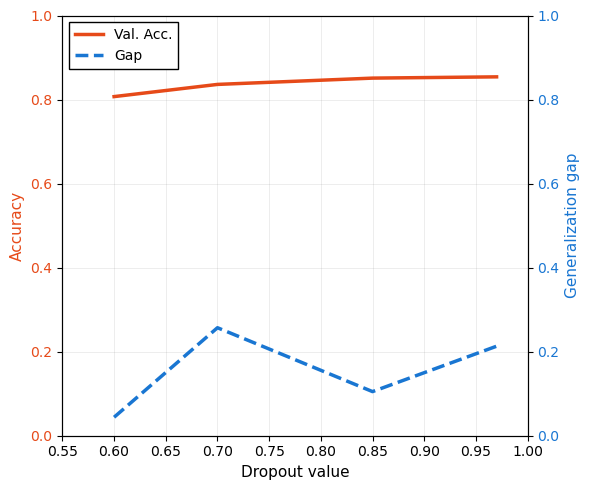

In [10]:
# =============================================================================
# FIGURE 4a: Dropout Regularization Results
# =============================================================================

# Data from Table 3 - Dropout experiments (CORRECTED)
dropout_data = {
    'incl_prob': [0.6, 0.7, 0.85, 0.97],
    'val_acc': [80.7, 83.6, 85.1, 85.4],  # ✓ From your Table 3
    'train_error': [0.549, 0.29, 0.329, 0.244],  # ✓ From your Table 3
    'val_error': [0.593, 0.547, 0.434, 0.457]  # ✓ From your Table 3
}

# Calculate generalization gap
dropout_data['gen_gap'] = [v - t for v, t in zip(dropout_data['val_error'], 
                                                   dropout_data['train_error'])]

# Baseline (no regularization)
baseline_val_acc = 83.7
baseline_gen_gap = 0.533 - 0.241  # val_error - train_error

# Create figure - similar style to reference
fig, ax1 = plt.subplots(figsize=(6, 5))
ax2 = ax1.twinx()

# Plot validation accuracy (left y-axis) - solid line
line1 = ax1.plot(dropout_data['incl_prob'], [v/100 for v in dropout_data['val_acc']], 
                 '-', color='#E64A19', linewidth=2.5, markersize=0, 
                 label='Val. Acc.', zorder=3)

# Plot generalization gap (right y-axis) - dashed line  
line2 = ax2.plot(dropout_data['incl_prob'], dropout_data['gen_gap'], 
                 '--', color='#1976D2', linewidth=2.5, markersize=0, 
                 label='Gap', zorder=3)

# Formatting
ax1.set_xlabel('Dropout value', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11, color='#E64A19')
ax1.tick_params(axis='y', labelcolor='#E64A19', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xlim([0.55, 1.0])
ax1.set_ylim([0.0, 1.0])
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, color='gray')

ax2.set_ylabel('Generalization gap', fontsize=11, color='#1976D2')
ax2.tick_params(axis='y', labelcolor='#1976D2', labelsize=10)
ax2.set_ylim([0, 1.0])

# Combined legend - in upper right
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10, frameon=True, 
          fancybox=False, edgecolor='black', framealpha=1.0)

plt.tight_layout()

# Save
plt.savefig('/Users/huez/mlpractical/report/figures/empty_dropout_plot.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: empty_dropout_plot.png")
plt.show()

✓ Saved: empty_wd_plot.png


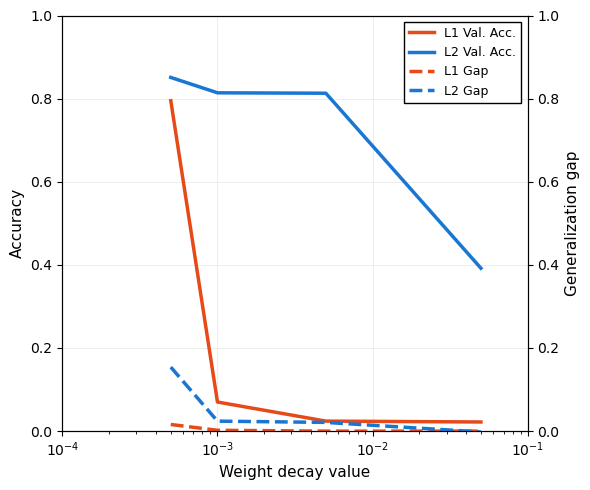

In [11]:
# =============================================================================
# FIGURE 4b: L1/L2 Weight Penalty Regularization Results
# =============================================================================

# Data from Table 3 - L1 penalty experiments (CORRECTED)
l1_data = {
    'coefficients': [5e-4, 1e-3, 5e-3, 5e-2],
    'labels': ['5e-4', '1e-3', '5e-3', '5e-2'],
    'val_acc': [79.5, 7.00, 2.41, 2.20],  # ✓ From your Table 3
    'train_error': [0.642, 1.062, 3.850, 3.850],  # ✓ From your Table 3
    'val_error': [0.658, 1.064, 3.850, 3.850]  # ✓ From your Table 3
}

# Data from Table 3 - L2 penalty experiments (CORRECTED)
l2_data = {
    'coefficients': [5e-4, 1e-3, 5e-3, 5e-2],
    'labels': ['5e-4', '1e-3', '5e-3', '5e-2'],
    'val_acc': [85.1, 81.4, 81.3, 39.2],  # ✓ From your Table 3
    'train_error': [0.306, 0.600, 0.586, 2.258],  # ✓ From your Table 3
    'val_error': [0.460, 0.624, 0.607, 2.256]  # ✓ From your Table 3
}

# Calculate generalization gaps
l1_data['gen_gap'] = [v - t for v, t in zip(l1_data['val_error'], l1_data['train_error'])]
l2_data['gen_gap'] = [v - t for v, t in zip(l2_data['val_error'], l2_data['train_error'])]

# Baseline (no regularization)
baseline_val_acc = 83.7
baseline_gen_gap = 0.533 - 0.241

# Create figure - similar style to reference with log scale
fig, ax1 = plt.subplots(figsize=(6, 5))
ax2 = ax1.twinx()

# Plot L1 results - solid lines
line1 = ax1.plot(l1_data['coefficients'], [v/100 for v in l1_data['val_acc']], 
                 '-', color='#E64A19', linewidth=2.5, markersize=0, 
                 label='L1 Val. Acc.')
line2 = ax2.plot(l1_data['coefficients'], l1_data['gen_gap'], 
                 '--', color='#E64A19', linewidth=2.5, markersize=0, 
                 label='L1 Gap')

# Plot L2 results - solid lines
line3 = ax1.plot(l2_data['coefficients'], [v/100 for v in l2_data['val_acc']], 
                 '-', color='#1976D2', linewidth=2.5, markersize=0, 
                 label='L2 Val. Acc.')
line4 = ax2.plot(l2_data['coefficients'], l2_data['gen_gap'], 
                 '--', color='#1976D2', linewidth=2.5, markersize=0, 
                 label='L2 Gap')

# Formatting
ax1.set_xlabel('Weight decay value', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11, color='black')
ax1.tick_params(axis='y', labelcolor='black', labelsize=10)
ax1.tick_params(axis='x', labelsize=10)
ax1.set_xscale('log')  # Log scale for x-axis
ax1.set_xlim([1e-4, 1e-1])
ax1.set_ylim([0.0, 1.0])
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, color='gray')

ax2.set_ylabel('Generalization gap', fontsize=11, color='black')
ax2.tick_params(axis='y', labelcolor='black', labelsize=10)
ax2.set_ylim([0, 1.0])

# Combined legend
lines = line1 + line3 + line2 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=9, frameon=True, 
          fancybox=False, edgecolor='black', framealpha=1.0)

plt.tight_layout()

# Save
plt.savefig('/Users/huez/mlpractical/report/figures/empty_wd_plot.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved: empty_wd_plot.png")
plt.show()